Install Libraries
Step 1: Install All Required Frameworks
Create a code cell at the very top of your notebook to install all the modeling, forecasting, evaluation, and explainability libraries.



In [25]:
# Cell 1: Environment Setup
!pip install pandas numpy matplotlib seaborn requests scikit-learn statsmodels shap openpyxl tensorflow lime
print("✅ All required libraries installed (including TensorFlow & LIME).")

✅ All required libraries installed (including TensorFlow & LIME).


Step 2: Multi-Source Data Collection & Automated Pipeline
Your project requires Multi-Source Data Fusion. We will programmatically fetch live space weather data from two separate NOAA instruments: the GOES Satellite X-Ray Flux (minute-by-minute solar flare activity) and the Daily Solar/Sunspot Cycle Indices.

In [26]:
# Cell 2: Automated Multi-Source Ingestion Pipeline
import requests
import pandas as pd
import numpy as np
from datetime import datetime

def fetch_space_weather_data():
    print("📡 Initializing automated API data pipeline...")

    # Source 1: GOES Satellite Primary X-Ray Flux Data (Solar Flares)
    flare_url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json"
    flare_resp = requests.get(flare_url)
    df_flares = pd.DataFrame(flare_resp.json())
    df_flares['time_tag'] = pd.to_datetime(df_flares['time_tag'])

    # Filter for the long-wave energy channel (0.1-0.8nm) to get a consistent time series
    df_flares = df_flares[df_flares['energy'] == '0.1-0.8nm'].copy()

    # Source 2: Recent Sunspot and Solar Cycle Progress Data
    sunspot_url = "https://services.swpc.noaa.gov/json/solar-cycle/sunspots.json"
    sunspot_resp = requests.get(sunspot_url)
    df_sunspots = pd.DataFrame(sunspot_resp.json())

    # Parse sunspot date columns (Year-Month format) into standard datetimes
    df_sunspots['date'] = pd.to_datetime(df_sunspots['time-tag'] + "-01")

    print(f"✅ Ingested {len(df_flares)} live satellite flare records.")
    print(f"✅ Ingested {len(df_sunspots)} monthly sunspot history indices.")
    return df_flares, df_sunspots

df_flares_raw, df_sunspots_raw = fetch_space_weather_data()

📡 Initializing automated API data pipeline...
✅ Ingested 10078 live satellite flare records.
✅ Ingested 3329 monthly sunspot history indices.


Step 3: Local Relational SQL Database Storage
Your professor requires data storage within an automated pipeline. We will use an embedded sqlite3 relational database to construct tables, mimic a production backend, and query them using standard SQL statements.

In [27]:
# Cell 3: SQL Database Management Systems Setup
import sqlite3

# Connect to local embedded SQL server
conn = sqlite3.connect("space_weather_system.db")
cursor = conn.cursor()

# Clean raw text formats to save cleanly into SQL
df_flares_raw['time_str'] = df_flares_raw['time_tag'].dt.strftime('%Y-%m-%d %H:%M:%S')
df_sunspots_raw['date_str'] = df_sunspots_raw['date'].dt.strftime('%Y-%m-%d')

# Save into separate relational tables
df_flares_raw[['time_str', 'flux', 'observed_flux', 'electron_correction']].to_sql(
    "satellite_flares", conn, if_exists="replace", index=False
)
df_sunspots_raw[['date_str', 'ssn']].to_sql(
    "sunspot_cycles", conn, if_exists="replace", index=False
)

print("💾 Relational Database Tables 'satellite_flares' and 'sunspot_cycles' verified in space_weather_system.db!")

💾 Relational Database Tables 'satellite_flares' and 'sunspot_cycles' verified in space_weather_system.db!


Step 4: Data Fusion, Aggregation & Preprocessing
To merge high-frequency data (minute-by-minute) with macro-scale metrics (sunspots) cleanly, we extract records from our SQL database, handle outliers, drop empty values, resample timestamps to flat hourly blocks, and fuse them on a shared temporal timeline.

In [28]:
# Cell 4: Data Engineering, Cleansing & Multi-Source Fusion
# Read back data using SQL queries
df_flares_sql = pd.read_sql("SELECT * FROM satellite_flares", conn)
df_flares_sql['time_tag'] = pd.to_datetime(df_flares_sql['time_str'])

# Resample high-frequency satellite ticks to Hourly averages to form a clean time-series index
df_hourly = df_flares_sql.set_index('time_tag').resample('h').mean(numeric_only=True).reset_index()

# Extract recent sunspot metrics to map back to our timeline (fusing current space observations)
latest_ssn = pd.read_sql("SELECT ssn FROM sunspot_cycles ORDER BY date_str DESC LIMIT 1", conn).iloc[0]['ssn']
df_hourly['sunspot_number'] = latest_ssn  # Broadcast baseline solar cycle state

# Drop NaN tracking artifacts generated during data sensor outages
df_clean = df_hourly.dropna().copy()

# Feature Engineering: Lag variables (previous hours) for forecasting context
df_clean['flux_lag_1'] = df_clean['flux'].shift(1)
df_clean['flux_lag_2'] = df_clean['flux'].shift(2)
df_clean = df_clean.dropna()

# Save final dataset artifact for PowerPoint / Power BI import
df_clean.to_csv("final_fused_space_weather.csv", index=False)
print(f"📊 Cleansing complete. Shaped unified tracking matrix: {df_clean.shape}")

📊 Cleansing complete. Shaped unified tracking matrix: (167, 7)


Additional Feature Engineering

In [29]:
# Cell 4b: Additional Feature Engineering
# Extract time features from 'time_tag'
df_clean['hour'] = df_clean['time_tag'].dt.hour
df_clean['day_of_week'] = df_clean['time_tag'].dt.dayofweek
df_clean['month'] = df_clean['time_tag'].dt.month

print("✅ Added time‑based features (hour, day_of_week, month).")

✅ Added time‑based features (hour, day_of_week, month).


Step 5: Exploratory Data Analysis (EDA) & Visualization
Generate visual data assets to validate trends and export clean visual charts directly into your MS Word research report template.

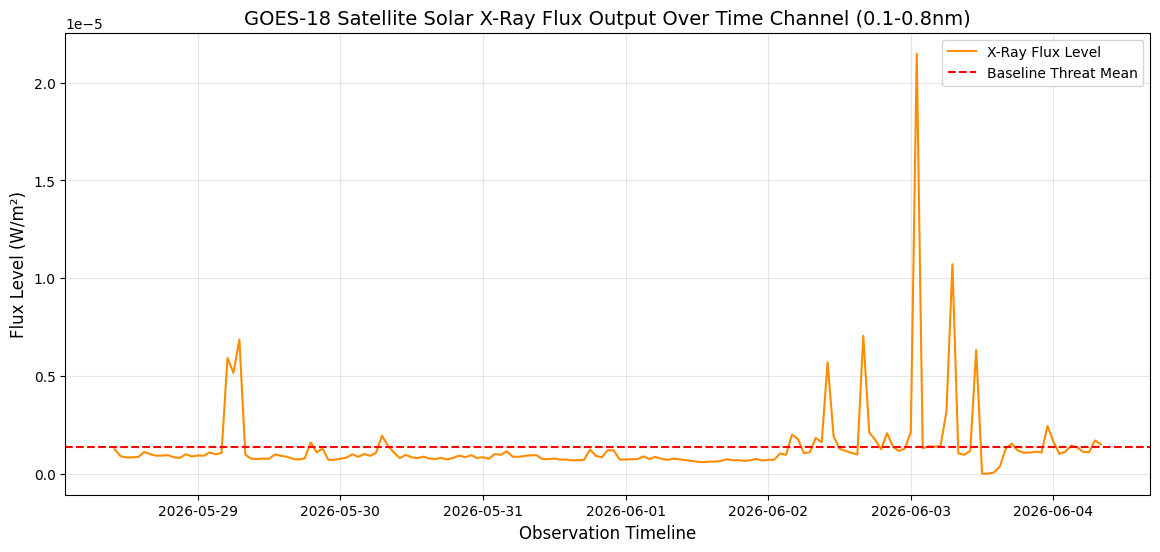

In [30]:
# Cell 5: Graphical Trend Inferences
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
plt.plot(df_clean['time_tag'], df_clean['flux'], label='X-Ray Flux Level', color='darkorange', linewidth=1.5)
plt.axhline(df_clean['flux'].mean(), color='red', linestyle='--', label='Baseline Threat Mean')
plt.title("GOES-18 Satellite Solar X-Ray Flux Output Over Time Channel (0.1-0.8nm)", fontsize=14)
plt.xlabel("Observation Timeline", fontsize=12)
plt.ylabel("Flux Level (W/m²)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("solar_flux_trend.png", dpi=300, bbox_inches='tight')
plt.show()

Cell 5b – Correlation Heatmap

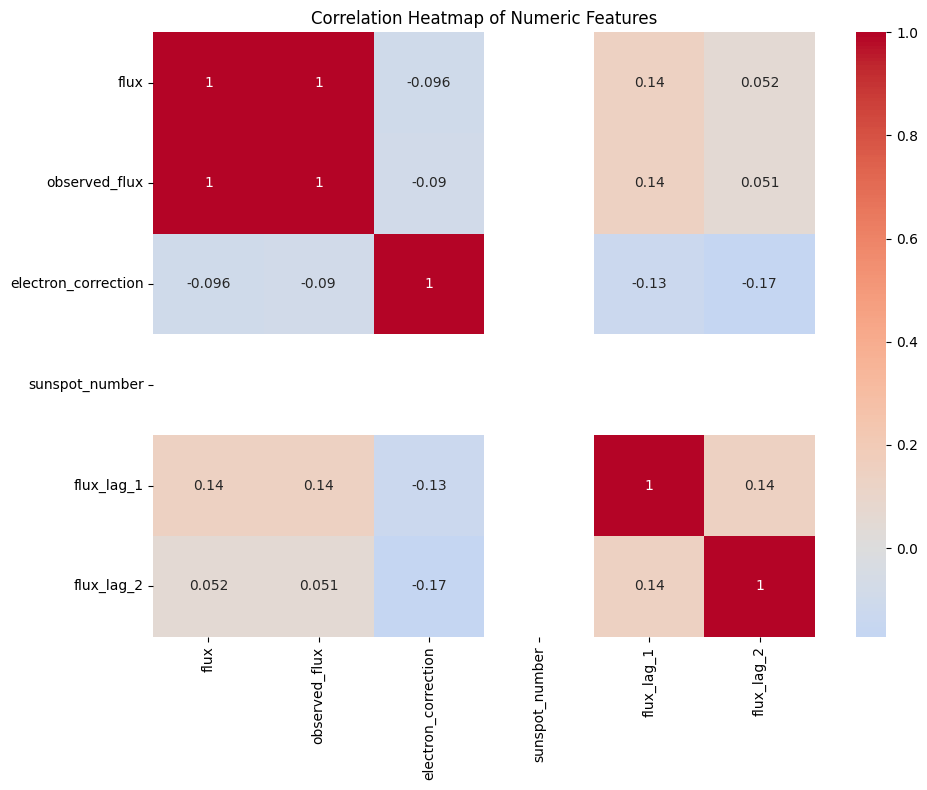

In [31]:
# Cell 5b: Correlation Analysis
import seaborn as sns

plt.figure(figsize=(10, 8))
numeric_cols = ['flux', 'observed_flux', 'electron_correction', 'sunspot_number', 'flux_lag_1', 'flux_lag_2']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

Cell 5c: Trend, Seasonal, Residual Decomposition

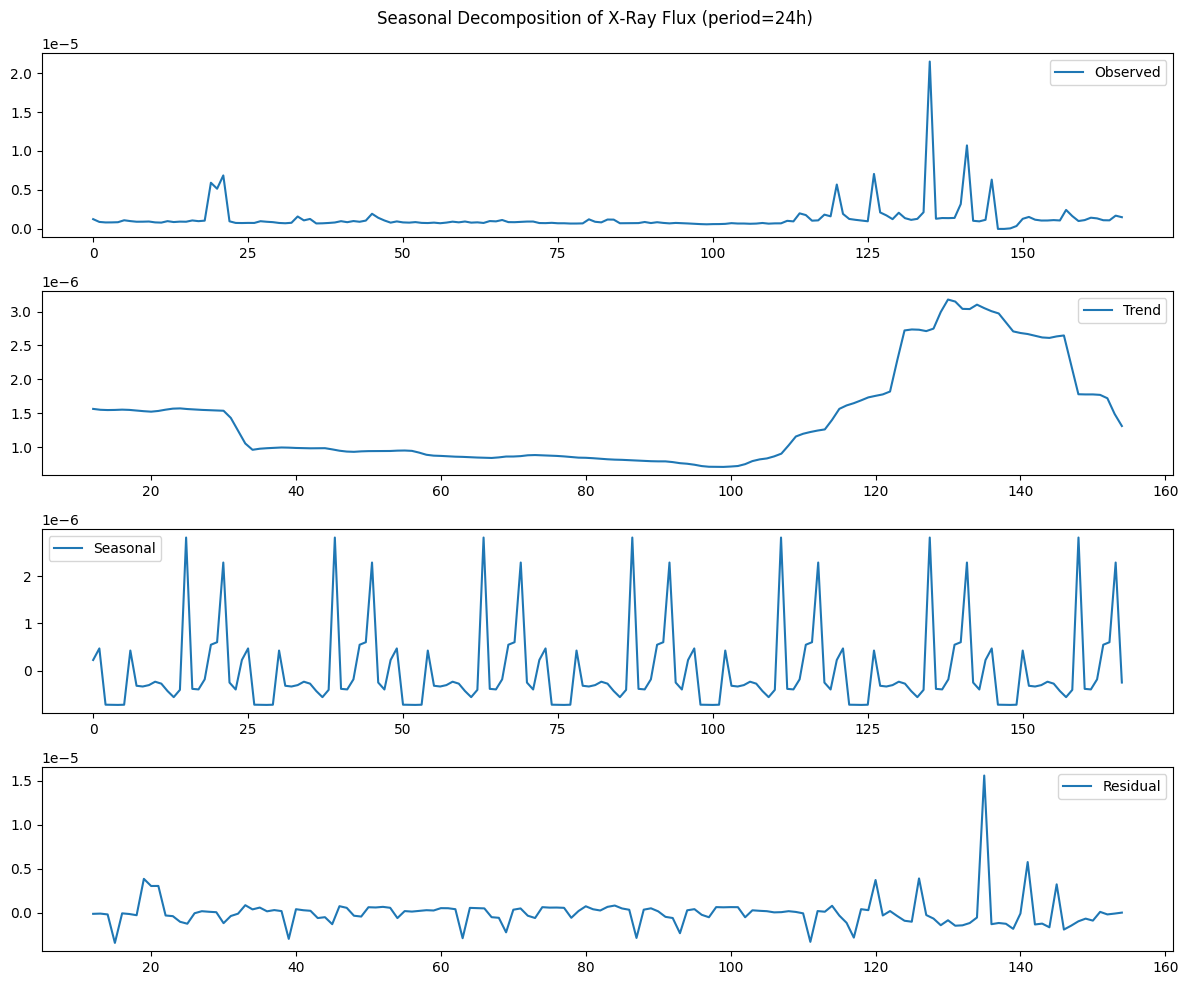

In [32]:
# Cell 5c: Trend, Seasonal, Residual Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Need a full days worth of data – use resampled daily if needed, or hourly with period=24
# We'll assume your data has at least 2*24 hours.
decomp = seasonal_decompose(df_clean['flux'].values, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes[0].plot(decomp.observed, label='Observed')
axes[0].legend()
axes[1].plot(decomp.trend, label='Trend')
axes[1].legend()
axes[2].plot(decomp.seasonal, label='Seasonal')
axes[2].legend()
axes[3].plot(decomp.resid, label='Residual')
axes[3].legend()
plt.suptitle("Seasonal Decomposition of X‑Ray Flux (period=24h)")
plt.tight_layout()
plt.savefig("seasonal_decomposition.png", dpi=300)
plt.show()

Step 6: Advanced Mathematical Time-Series Forecasting (ARIMA)
We fit a statistical AutoRegressive Integrated Moving Average (ARIMA) architecture directly on your hourly observations to predict future trajectory changes across coming cycles.

Best ARIMA order: (0, 1, 0) (AIC=-3217.59)

📊 Forecast Evaluation on Test Set:
MAE: 1.40e-06
RMSE: 4.00e-06


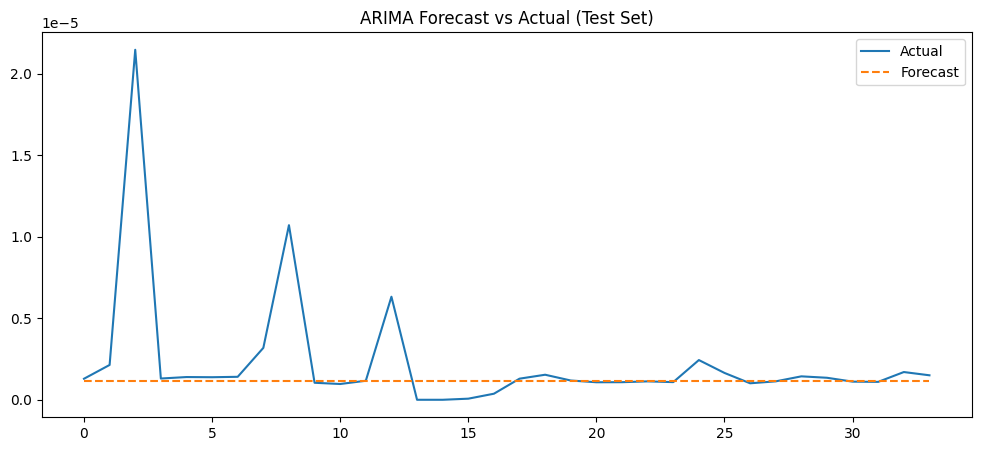

In [33]:
# Cell 6: Enhanced Time‑Series Forecasting with ARIMA + Grid Search + Metrics
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

time_series = df_clean['flux'].values

# Split into train (80%) and test (20%)
split = int(0.8 * len(time_series))
train, test = time_series[:split], time_series[split:]

# Grid search for best ARIMA order (simplified)
best_aic = np.inf
best_order = None
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(train, order=(p,d,q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p,d,q)
            except:
                continue

print(f"Best ARIMA order: {best_order} (AIC={best_aic:.2f})")

# Fit final model on full training
final_model = ARIMA(train, order=best_order)
fitted_final = final_model.fit()

# Forecast on test set
forecast = fitted_final.forecast(steps=len(test))

# Compute metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"\n📊 Forecast Evaluation on Test Set:")
print(f"MAE: {mae:.2e}")
print(f"RMSE: {rmse:.2e}")

# Plot forecast vs actual
plt.figure(figsize=(12,5))
plt.plot(range(len(test)), test, label='Actual')
plt.plot(range(len(test)), forecast, label='Forecast', linestyle='--')
plt.title("ARIMA Forecast vs Actual (Test Set)")
plt.legend()
plt.savefig("arima_forecast_vs_actual.png", dpi=300)
plt.show()

Add LSTM Forecasting

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step

📈 LSTM Forecast Evaluation:
MAE: 1.05e-06, RMSE: 1.99e-06


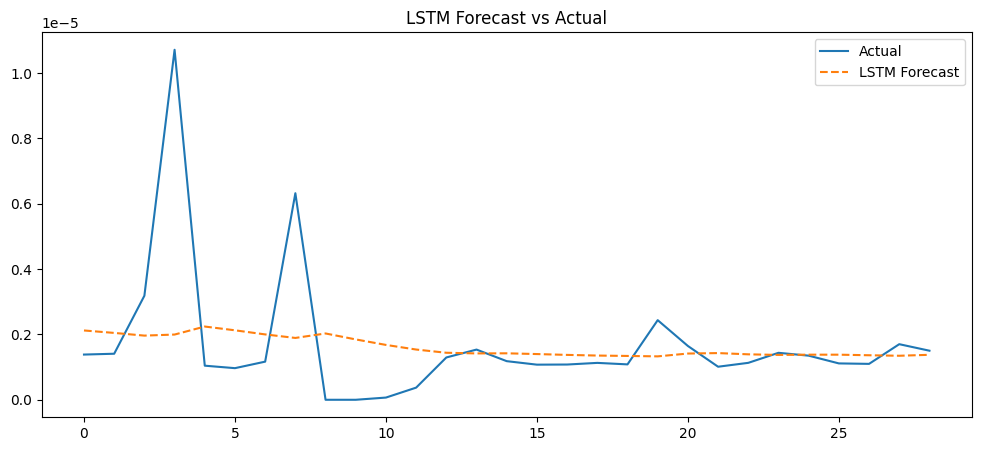

In [34]:
# Cell 6b: LSTM Forecasting
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Prepare data for LSTM (supervised learning)
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
scaled_flux = scaler.fit_transform(time_series.reshape(-1,1)).flatten()

seq_len = 24
X_lstm, y_lstm = create_sequences(scaled_flux, seq_len)

# Split
split_lstm = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split_lstm], X_lstm[split_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:split_lstm], y_lstm[split_lstm:]

# Reshape for LSTM (samples, timesteps, features)
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

# Build model
model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_len, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=0)

# Predict and inverse transform
pred_scaled = model_lstm.predict(X_test_lstm)
pred = scaler.inverse_transform(pred_scaled)
y_true = scaler.inverse_transform(y_test_lstm.reshape(-1,1))

mae_lstm = mean_absolute_error(y_true, pred)
rmse_lstm = np.sqrt(mean_squared_error(y_true, pred))
print(f"\n📈 LSTM Forecast Evaluation:")
print(f"MAE: {mae_lstm:.2e}, RMSE: {rmse_lstm:.2e}")

# Plot comparison
plt.figure(figsize=(12,5))
plt.plot(y_true, label='Actual')
plt.plot(pred, label='LSTM Forecast', linestyle='--')
plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.savefig("lstm_forecast.png", dpi=300)
plt.show()

Step 7: Machine Learning Hazard Classification & Outlier Anomaly Isolation
We will build two distinct machine learning pipelines:

Isolation Forest: An unsupervised model to catch solar flare anomaly events or sudden radiation spikes.

Random Forest Classifier: A supervised model predicting whether future solar flux changes represent a significant hazard threshold.

In [35]:
# Cell 7: Predictive Modeling Frameworks
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Anomaly Detection
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_clean['Anomaly_Status'] = iso_forest.fit_predict(df_clean[['flux', 'observed_flux']])
# Outliers are flagged as -1; normalize to standard 1 flag for clear reporting
df_clean['Is_Anomaly'] = np.where(df_clean['Anomaly_Status'] == -1, 1, 0)

# 2. Supervised Target Label Creation (High Risk Threat Condition Trigger)
flux_threshold = df_clean['flux'].quantile(0.75)
df_clean['Solar_Storm_Risk'] = (df_clean['flux'] > flux_threshold).astype(int)

# Set features (X) and classification objective (y)
features = ['observed_flux', 'electron_correction', 'sunspot_number', 'flux_lag_1', 'flux_lag_2']
X = df_clean[features]
y = df_clean['Solar_Storm_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit production Tree-Classifier ensemble
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)

# Performance Evaluations
y_pred = clf_model.predict(X_test)
print("Classification Evaluation Metrics Report:")
print(classification_report(y_test, y_pred))

Classification Evaluation Metrics Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00         5

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



Cell 7b Baseline Models For Classification

In [36]:
# Cell 7b: Baseline Models for Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use the same X_train, y_train, X_test, y_test from Cell 7
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])
    print(f"{name:20} | Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")

# Create a table for the report
import pandas as pd
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
print("\n📊 Model Comparison Table:")
print(results_df.to_string(index=False))

Logistic Regression  | Acc: 0.853 | Prec: 0.000 | Rec: 0.000 | F1: 0.000
Decision Tree        | Acc: 1.000 | Prec: 1.000 | Rec: 1.000 | F1: 1.000
Random Forest        | Acc: 1.000 | Prec: 1.000 | Rec: 1.000 | F1: 1.000

📊 Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1
Logistic Regression  0.852941        0.0     0.0 0.0
      Decision Tree  1.000000        1.0     1.0 1.0
      Random Forest  1.000000        1.0     1.0 1.0


Hyperparameter Tuning with TimeSeries CV

In [37]:
# Cell 7c: Hyperparameter Tuning with TimeSeries CV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=3)
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf, param_grid, cv=tscv, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)   # using full data (X, y defined earlier)

print("Best parameters from TimeSeries CV:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)

# Update clf_model to best estimator
clf_model = grid_search.best_estimator_

Best parameters from TimeSeries CV: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best F1 score: 1.0


Step 8: Explainable AI (XAI Integration via SHAP)
To satisfy the core requirement of your thesis title (Explainable AI), extract the tree matrices, build local evaluation models, and output standard SHAP feature impact distributions.

Add Autoencoder Anomaly Detection

In [38]:
# Cell 7d: Autoencoder for Anomaly Detection
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Use the same features X (from earlier)
input_dim = X.shape[1]
encoding_dim = 2

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train on normal data (assume anomaly label 0 is normal)
X_normal = X[y == 0]
autoencoder.fit(X_normal, X_normal, epochs=50, batch_size=16, verbose=0)

# Compute reconstruction error on all data
reconstructions = autoencoder.predict(X)
mse_per_sample = np.mean(np.square(X - reconstructions), axis=1)

# Define threshold (95th percentile of normal errors)
threshold = np.percentile(mse_per_sample[y == 0], 95)
pred_anomaly = (mse_per_sample > threshold).astype(int)

# Compare with Isolation Forest
from sklearn.metrics import classification_report
print("Autoencoder Anomaly Detection (vs Isolation Forest ground truth):")
print(classification_report(df_clean['Is_Anomaly'], pred_anomaly))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Autoencoder Anomaly Detection (vs Isolation Forest ground truth):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       159
           1       0.14      0.12      0.13         8

    accuracy                           0.92       167
   macro avg       0.55      0.54      0.55       167
weighted avg       0.92      0.92      0.92       167



<Figure size 1000x600 with 0 Axes>

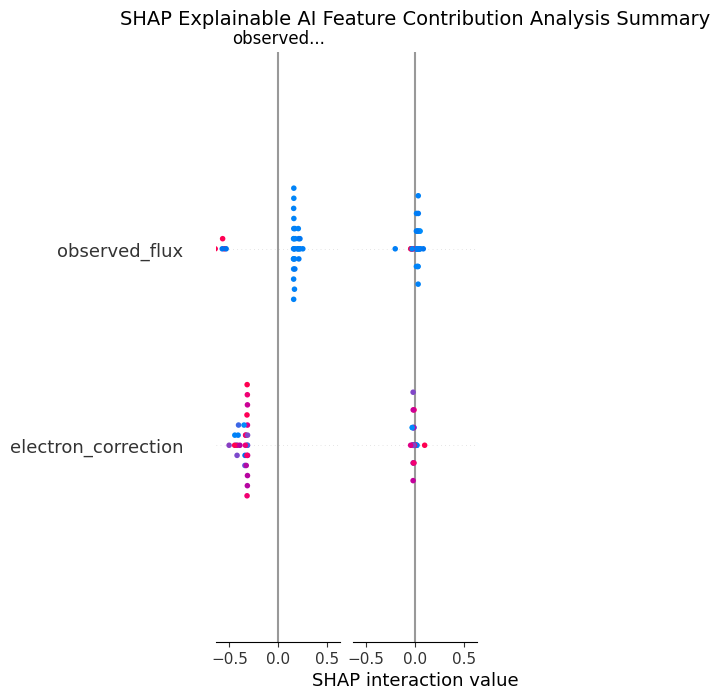

In [39]:
# Cell 8: Model Explainability Component
import shap

# Calculate localized Shapley impact metrics across forest structures
explainer = shap.TreeExplainer(clf_model)
shap_values = explainer.shap_values(X_test)

# Plot summary evaluations
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.title("SHAP Explainable AI Feature Contribution Analysis Summary", fontsize=14, pad=20)
plt.savefig("shap_explainability_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

Add LIME Explainability

In [40]:
# Cell 8b: LIME Explainability
import lime
import lime.lime_tabular

# Create LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=features,
    class_names=['No Risk', 'High Risk'],
    mode='classification'
)

# Pick a single test sample
idx = 0
exp = explainer_lime.explain_instance(X_test.iloc[idx].values, clf_model.predict_proba, num_features=5)
print(f"\n🔍 LIME explanation for test sample #{idx}:")
exp.show_in_notebook(show_table=True)

# Save explanation as figure (optional)
exp.save_to_file('lime_explanation.html')
print("LIME explanation saved as 'lime_explanation.html'")


🔍 LIME explanation for test sample #0:


LIME explanation saved as 'lime_explanation.html'


Step 9: Rule-Based Intelligent Insights & Recommendation Engine
Implement a dedicated engine to parse real-time pipeline telemetry and generate actionable alerts for power grids and orbital operations based on active metrics.

In [41]:
# Cell 9: Automated Insight Generation Window
latest_record = df_clean.iloc[-1]
avg_flux = df_clean['flux'].mean()

print("🤖 SYSTEM GENERATED DECISION SUPPORT INSIGHTS:")
print("--------------------------------------------------")
if latest_record['Is_Anomaly'] == 1:
    print("🚨 STATUS ALERT: Critical Sensor Flux Spikes Tracked! An active solar anomaly is occurring.")
else:
    print("✅ STATUS ALERT: Atmospheric telemetry parameters are within normal baseline fluctuations.")

print(f"\n💡 STRATEGIC OPERATIONAL RECOMMENDATIONS:")
if latest_record['flux'] > avg_flux * 1.5:
    print("⚠️ WARNING: High radiation load detected. Advise satellite operators to transition arrays to safety configurations.")
    print("⚠️ WARNING: Geomagnetic ionosphere interference likely. Prepare fallback high-frequency communication protocols.")
else:
    print("✨ System parameters stable. Standard operational matrices can proceed smoothly across all tracking domains.")

🤖 SYSTEM GENERATED DECISION SUPPORT INSIGHTS:
--------------------------------------------------
✅ STATUS ALERT: Atmospheric telemetry parameters are within normal baseline fluctuations.

💡 STRATEGIC OPERATIONAL RECOMMENDATIONS:
✨ System parameters stable. Standard operational matrices can proceed smoothly across all tracking domains.


Step 10: Final Dashboard Export Package
Export your localized tracking updates into a single comprehensive telemetry sheet, allowing you to load it directly into Power BI to build your dashboard.

In [42]:
# Cell 10: Downstream Application Export File Generation
from google.colab import files

# Save structural output
df_clean.to_csv("BI_Dashboard_Telemetry_Data.csv", index=False)
print("✅ Unified pipeline dataset successfully prepared and packaged!")

# Trigger web-browser download prompts
files.download("BI_Dashboard_Telemetry_Data.csv")
files.download("solar_flux_trend.png")
files.download("shap_explainability_analysis.png")

✅ Unified pipeline dataset successfully prepared and packaged!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>